# Week 4 — Sequential Posterior Updating on NHANES

*INFO 521 worked notebook (Module 4). Companion to lectures m4a/m4b. Needs the course
environment (`info521` package).*

Two conjugate updates, both on real patients: the **Beta–Binomial** for the hypertension
proportion (the week's activity model), then the **conjugate Gaussian posterior** over the
regression weights — the closed form where **Project 1 ends**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import lgamma
from info521.data import load_clinical, primary_predictor, hypertension

BLUE, VERMILLION, GREEN, ORANGE, PURPLE = "#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7"
rng = np.random.default_rng(521)

ds = load_clinical()
labels, rule = hypertension(ds)          # ACC/AHA: SBP≥130 or DBP≥80 (measured BP only)
print(rule, "| prevalence:", round(labels.mean(), 4))

SBP>=130 OR DBP>=80 (ACC/AHA stage-1 hypertension) | prevalence: 0.3883


## Beta–Binomial: belief, one patient at a time

Prior $\mathrm{Beta}(a,b)$; after $n_1$ positives and $n_0$ negatives the posterior is
$\mathrm{Beta}(a+n_1,\ b+n_0)$ — the update is **addition**. Screen NHANES adults in a
fixed random order and watch belief converge:

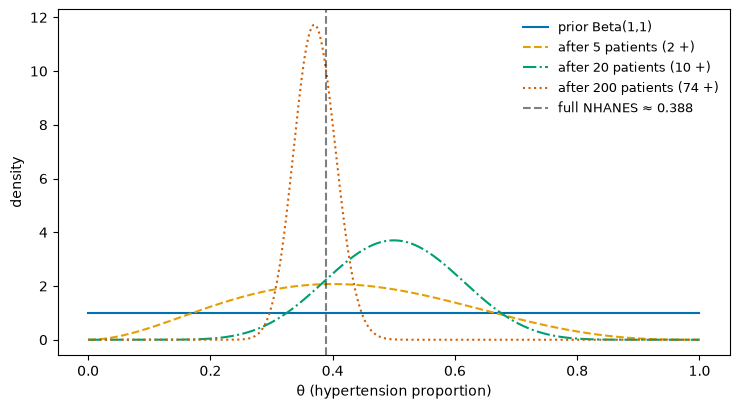

In [2]:
def beta_pdf(t, a, b):
    logB = lgamma(a) + lgamma(b) - lgamma(a + b)
    return np.exp((a-1)*np.log(t) + (b-1)*np.log(1-t) - logB)

tgrid = np.linspace(1e-4, 1-1e-4, 500)
order = rng.permutation(len(labels))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for n, col, ls in [(0, BLUE, "-"), (5, ORANGE, "--"), (20, GREEN, "-."), (200, VERMILLION, ":")]:
    n1 = int(labels[order[:n]].sum())
    lab = "prior Beta(1,1)" if n == 0 else f"after {n} patients ({n1} +)"
    ax.plot(tgrid, beta_pdf(tgrid, 1+n1, 1+n-n1), color=col, linestyle=ls, label=lab)
ax.axvline(labels.mean(), color="k", linestyle="--", alpha=0.5,
           label=f"full NHANES ≈ {labels.mean():.3f}")
ax.set_xlabel("θ (hypertension proportion)"); ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

The posterior mean is a **weighted blend** of prior mean and sample frequency — as $N$
grows, the data weight → 1. With enough patients, the prior is a rounding error.

## The conjugate Gaussian posterior for w

Gaussian prior $\mathcal{N}(\mathbf{m}_0, \mathbf{S}_0)$ × Gaussian likelihood (known
$\sigma^2$) → Gaussian posterior, in closed form (lecture m4b):

$$\mathbf{S}_N = \left(\mathbf{S}_0^{-1} + \tfrac{1}{\sigma^2}\mathbf{X}^{\!\top}\mathbf{X}\right)^{-1},
\qquad \mathbf{m}_N = \mathbf{S}_N\left(\mathbf{S}_0^{-1}\mathbf{m}_0 + \tfrac{1}{\sigma^2}\mathbf{X}^{\!\top}\mathbf{y}\right)$$

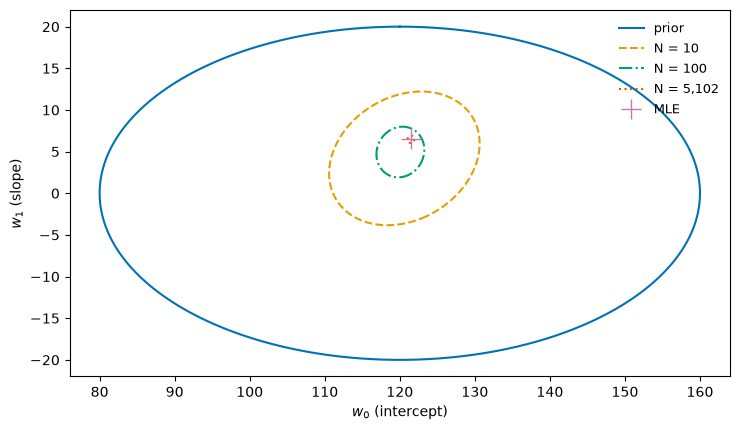

In [3]:
age = primary_predictor(ds); sbp = ds["y"]
z   = (age - age.mean()) / age.std()
X   = np.column_stack([np.ones_like(z), z]); N = len(sbp)
w_mle = np.linalg.solve(X.T @ X, X.T @ sbp)
s2    = float(((sbp - X @ w_mle)**2).mean())     # m3's σ̂², treated as known

m0 = np.array([120.0, 0.0])                      # "SBP near 120, no age effect"
S0 = np.diag([20.0**2, 10.0**2])                 # ...held loosely

def posterior(Xs, ys):
    S0inv = np.linalg.inv(S0)
    SN = np.linalg.inv(S0inv + (Xs.T @ Xs)/s2)
    mN = SN @ (S0inv @ m0 + (Xs.T @ ys)/s2)
    return mN, SN

def ellipse(mean, cov, nsig=2.0):
    vals, vecs = np.linalg.eigh(cov)
    t = np.linspace(0, 2*np.pi, 240)
    pts = vecs @ (np.sqrt(vals)[:, None] * nsig * np.stack([np.cos(t), np.sin(t)]))
    return mean[0] + pts[0], mean[1] + pts[1]

idx = rng.permutation(N)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for n, col, ls in [(0, BLUE, "-"), (10, ORANGE, "--"), (100, GREEN, "-."), (N, VERMILLION, ":")]:
    mN, SN = (m0, S0) if n == 0 else posterior(X[idx[:n]], sbp[idx[:n]])
    ex, ey = ellipse(mN, SN)
    ax.plot(ex, ey, color=col, linestyle=ls,
            label="prior" if n == 0 else f"N = {n:,}")
ax.plot(*w_mle, marker="+", ms=14, color=PURPLE, linestyle="none", label="MLE")
ax.set_xlabel("$w_0$ (intercept)"); ax.set_ylabel("$w_1$ (slope)")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

**Precisions add**: $\mathbf{S}_N^{-1} = \mathbf{S}_0^{-1} + \frac{1}{\sigma^2}\mathbf{X}^\top\mathbf{X}$
— prior information + data information (the Fisher matrix, again). As $N \to \infty$ the
posterior contracts onto the MLE.

**Try it yourself:** set $\mathbf{m}_0 = \mathbf{0}$, $\mathbf{S}_0 = \tau^2\mathbf{I}$ and
compare $\mathbf{m}_N$ with the ridge solution
$(\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$ at
$\lambda = \sigma^2/\tau^2$. They should agree to machine precision — ridge **is** MAP.